---
Author: The Tuan Trinh \
Date: 2026-05-30
---

In [1]:
import os
import platform
print("=" * 100)
print("OS Name:", os.name)
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Platform:", platform.platform())

print("\nEnvironment Variables (sample):")
for key, value in list(os.environ.items())[:15]:
    print(f"{key} = {value}")

OS Name: posix
System: Linux
Release: 6.6.122+
Machine: x86_64
Processor: x86_64
Platform: Linux-6.6.122+-x86_64-with-glibc2.35

Environment Variables (sample):
SHELL = /bin/bash
COLAB_JUPYTER_TRANSPORT = ipc
CGROUP_MEMORY_EVENTS = /sys/fs/cgroup/memory.events /var/colab/cgroup/jupyter-children/memory.events
VM_GCE_METADATA_HOST = 169.254.169.253
MODEL_PROXY_HOST = https://mp.kaggle.net
HOSTNAME = 81f94d2e7c78
LANGUAGE = en_US
TBE_RUNTIME_ADDR = 172.28.0.1:8011
GCE_METADATA_TIMEOUT = 3
COLAB_JUPYTER_IP = 172.28.0.12
KMP_LISTEN_PORT = 6000
TF_FORCE_GPU_ALLOW_GROWTH = true
ENV = /root/.bashrc
PWD = /
TBE_EPHEM_CREDS_ADDR = 172.28.0.1:8009


In [2]:
platform.python_version()

'3.12.13'

In [3]:
import numpy as np


class Conv2D:
    def __init__(self, kernel,
                       stride=1,
                       padding=0):
        """
        kernel       : 2D numpy array
        stride       : step size
        padding      : zero padding
        """
        self.kernel = kernel
        self.stride = stride
        self.padding = padding
        # self.flip_kernel = flip_kernel

    def forward(self, image):
        kernel = self.kernel
        # # Flip kernel for true convolution
        # if self.flip_kernel:
        #     kernel = np.flipud(np.fliplr(kernel))
        H, W = image.shape
        kH, kW = kernel.shape
        padded_image = np.pad(
            image,
            ((self.padding, self.padding),
             (self.padding, self.padding)),
            mode='constant'
        )
        out_H = (H + 2 * self.padding - kH) // self.stride + 1
        out_W = (W + 2 * self.padding - kW) // self.stride + 1
        output = np.zeros((out_H, out_W))
        # Convolution operation
        for y in range(out_H):
            for x in range(out_W):
                region = padded_image[
                    y*self.stride:y*self.stride+kH,
                    x*self.stride:x*self.stride+kW
                ]
                output[y, x] = np.sum(region * kernel)

        return output

In [4]:
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

url = "https://64.media.tumblr.com/2d2b8515e30477587db32e5906960193/tumblr_nhs39ksylA1tawn8uo1_1280.jpg"
resp = urllib.request.urlopen(url)
img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img_pil = Image.open(io.BytesIO(img))

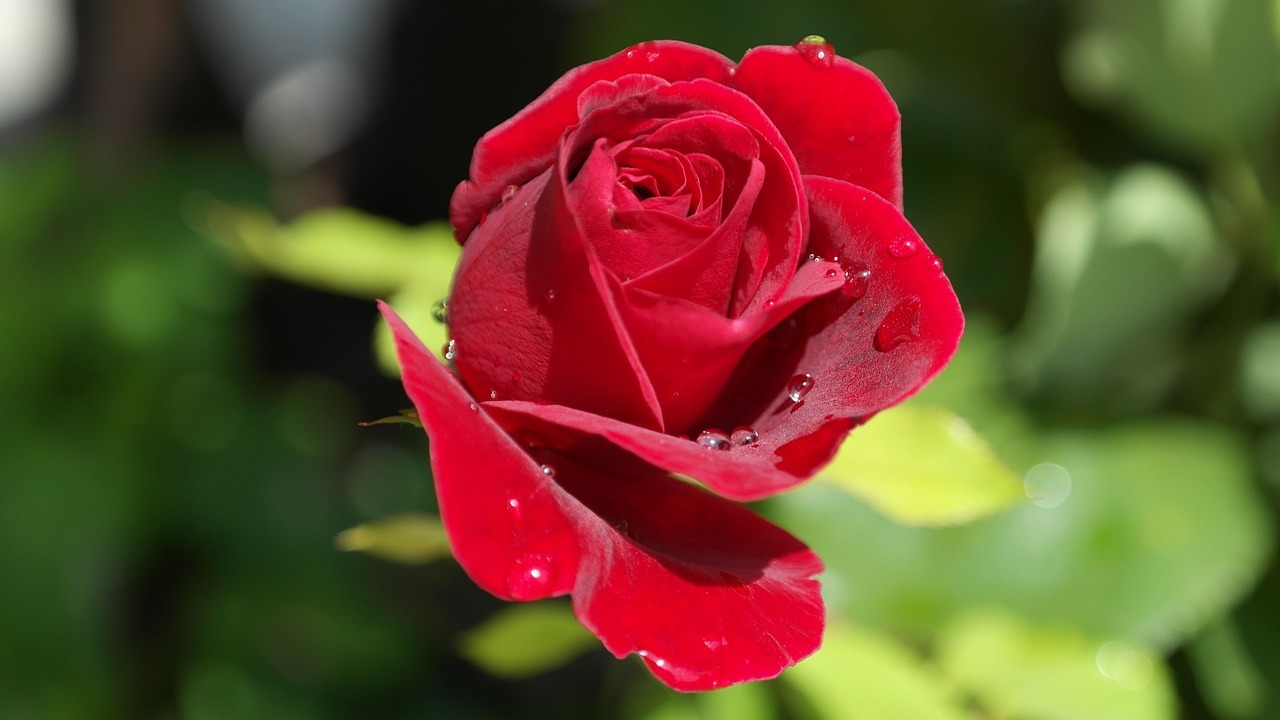

In [5]:
img_pil

## From scratch

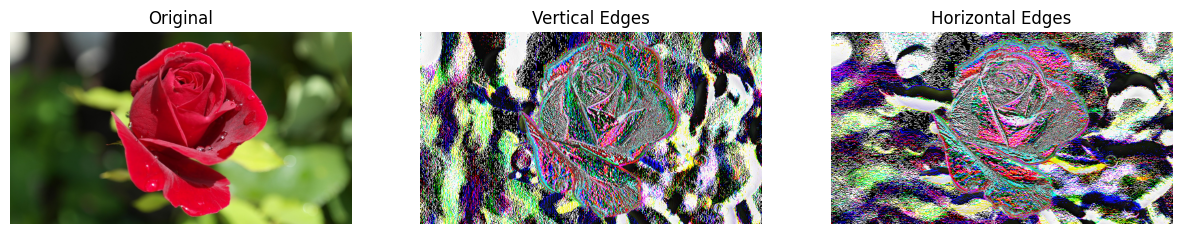

In [6]:
img_np = np.array(img_pil, dtype=np.float32)

kernel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

kernel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

conv_x = Conv2D(kernel_x, padding=0)
conv_y = Conv2D(kernel_y, padding=0)

edge_x_channels = []
edge_y_channels = []

for c in range(3):
    channel = img_np[:, :, c]
    edge_x = conv_x.forward(channel)
    edge_y = conv_y.forward(channel)
    edge_x_channels.append(edge_x)
    edge_y_channels.append(edge_y)

edge_x_rgb = np.stack(edge_x_channels, axis=2)
edge_y_rgb = np.stack(edge_y_channels, axis=2)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(img_np.astype(np.uint8))
plt.title("Original")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(edge_x_rgb.astype(np.uint8))
plt.title("Vertical Edges")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(edge_y_rgb.astype(np.uint8))
plt.title("Horizontal Edges")
plt.axis("off")
plt.show()

# cv2 library

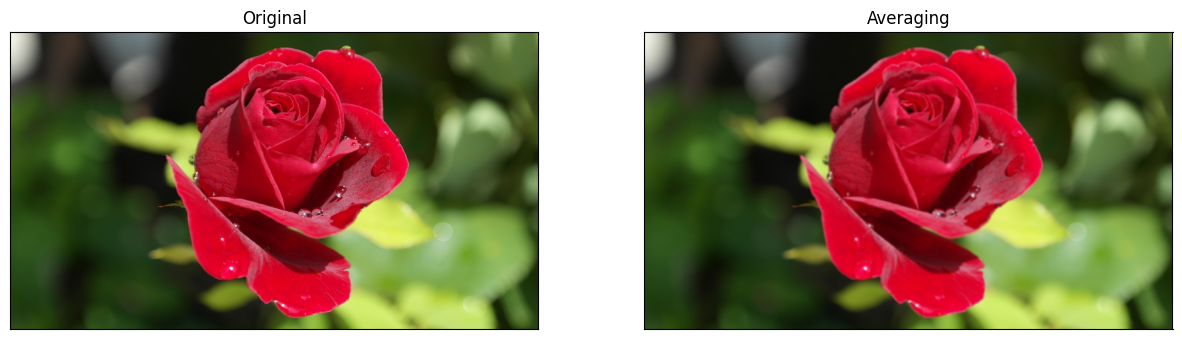

In [7]:
import cv2

kernel = np.ones((5,5),np.float32)/25
img_np = np.array(img_pil, dtype=np.float32)
dst = cv2.filter2D(np.array(img_np),-1,kernel)

plt.figure(figsize=(15,5))
plt.subplot(121),
plt.imshow(img_np.astype(np.uint8)),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(dst.astype(np.uint8)),plt.title('Averaging')
plt.xticks([]), plt.yticks([])
plt.show()

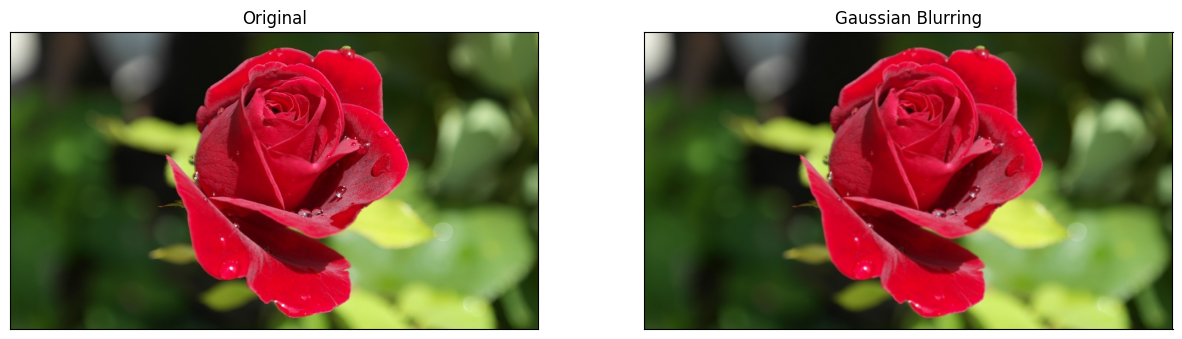

In [8]:
blur = cv2.GaussianBlur(img_np,(5,5),0)
plt.figure(figsize=(15,5))
plt.subplot(121),
plt.imshow(img_np.astype(np.uint8)),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur.astype(np.uint8)),plt.title('Gaussian Blurring')
plt.xticks([]), plt.yticks([])
plt.show()

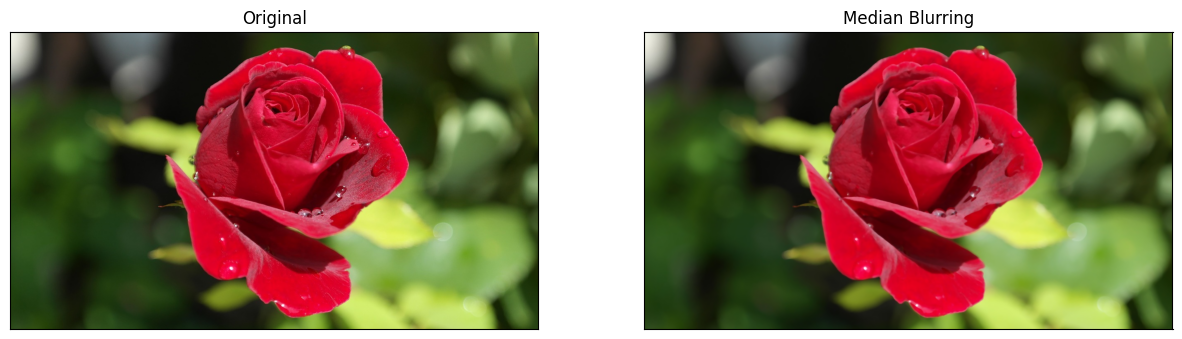

In [9]:
median = cv2.medianBlur(img_np,5)
plt.figure(figsize=(15,5))
plt.subplot(121),
plt.imshow(img_np.astype(np.uint8)),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(median.astype(np.uint8)),plt.title('Median Blurring')
plt.xticks([]), plt.yticks([])
plt.show()

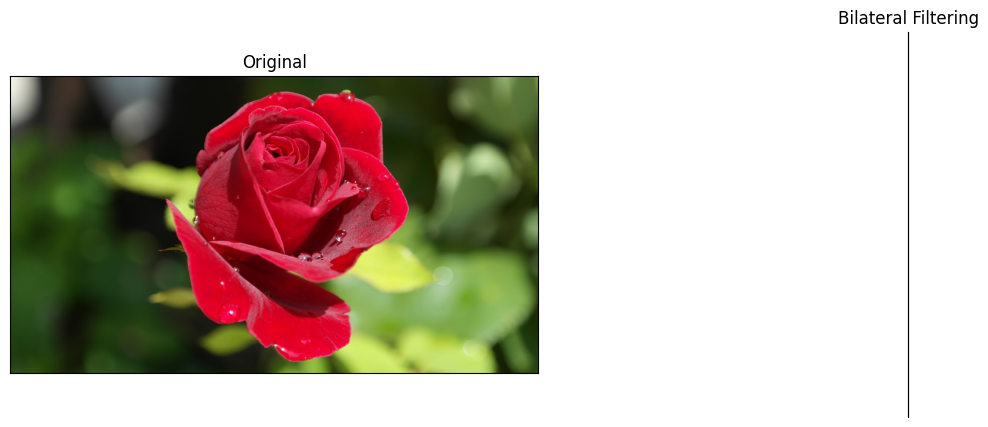

In [10]:
blur = cv2.bilateralFilter(img,9,75,75)
plt.figure(figsize=(15,5))
plt.subplot(121),
plt.imshow(img_np.astype(np.uint8)),plt.title('Original')
plt.xticks([]), plt.yticks([])
plt.subplot(122),plt.imshow(blur.astype(np.uint8)),plt.title('Bilateral Filtering')
plt.xticks([]), plt.yticks([])
plt.show()
